# Airglow modeling (with new framework)

In [23]:
%matplotlib widget
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from importlib import reload
from scipy import interpolate
import sys
import os
from scipy import signal
import obspy

import airglow_response as ar

## Airglow scaler
Take any moment tensor source $(M_w$, strike, dip, rake, depth$)$. 

Take a range of azimuth / distances to get some variability in waveforms. Normalize each velocity waveform by 1. Normalize each displacement waveform by the same factor as the velocity.

Calculate the intensity perturbation $100\Delta I/I_{\text{background}}$ (in %).

Plot the maximum in different frequency bands, centered (logaritmically) around 0.001 Hz, 0.01 Hz, 0.1 Hz and 1 Hz.

Total grid size:  441


100%|████████████████████████████████████████| 441/441 [00:00<00:00, 4498.47it/s]                                             

Size of VEL, DIS (bytes):  21168000


Using Balthasar Kenda's attenuation data
(East, North) location indices that will be saved:  []


100%|████████████████████████████████████████| 441/441 [00:02<00:00, 187.31it/s]                                              


...

Saving gridded wavefield...
Grid save completed.
(East, North) location indices that will be saved:  []


100%|████████████████████████████████████████| 441/441 [00:02<00:00, 159.51it/s]                                              


Time for dayglow calculation: 3.4 s
Re-aranging gridded dayglow wavefield...


100%|████████████████████████████████████████| 441/441 [00:00<00:00, 913.61it/s]                                              


Saving gridded dayglow wavefield...
Grid save completed.
 Filter bins:  [[None, 0.0031622776601683794], [0.0031622776601683794, 0.03162277660168379], [0.03162277660168379, 0.31622776601683794], [0.31622776601683794, None]]


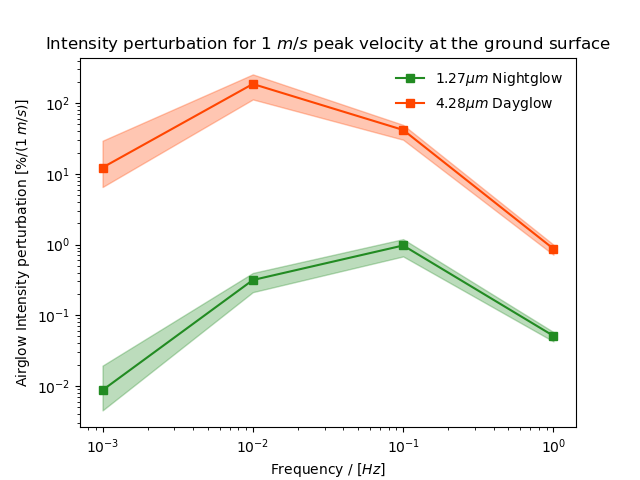

In [22]:
reload(ar)
ar.compute_airglow_scaler_new(mw = 1, strike=45, dip=45, rake=45, do_plot=True)
# ar.compute_airglow_scaler_new(mw = 5, strike=45, dip=45, rake=45, do_plot=True)  ### Check that this measure is independant of mw.
# ar.compute_airglow_scaler_new(mw = 1, strike=45, dip=0, rake=45, do_plot=True)
# ar.compute_airglow_scaler_new(mw = 1, strike=90, dip=0, rake=0, do_plot=True)    ### Check that this measure is independant of MT. 

## Determine airglow waveforms for specific examples
Converts seismic vertical velocities determined through QSSP into dayglow and nightglow Intensity perturbations

### Build QSSP traces

In [24]:
reload(ar)

### First, define the grid of locations. 
gridded       = False
min_grid_dist = 50e3
max_grid_dist = 8000e3 # 4000e3
delta_dist    = 50e3 
north_shifts  = np.arange( min_grid_dist, max_grid_dist, delta_dist)
east_shifts   = np.array([0. for i in range(north_shifts.size)])
    
### Source depths 
# delta_depth = 5e3
# depths = np.arange(5e3, 50e3+delta_depth, delta_depth)

### Option for Pyrocko 
opt_synthetics = dict(
    ### Options for source 
    mw = 6.5,              ### if none: We only get the Green's function
    depth = 10e3,          ### Only one depth
    strike = 0.,           ### Default mechanism 
    dip =  45., 
    rake = 45.,
    #stf_type = None,       ### Dirac source 
    #stf_type = 'triangle', 
    stf_type = 'sinus', 
    effective_duration = 25.,
    ###  
    ### Options for store
    base_folder='/projects/restricted/infrasound/data/infrasound/2023_Venus_inversion/',
    ### Old option, single store 
    #store_id = 'GF_venus_Cold100_qssp',
    #store_id = 'GF_venus_Cold100_qssp_grid',
    ### Give store names, and min and max valid distance 
    store_ids_dists = [('GF_venus_Cold100_qssp_grid',0e3,500e3),('GF_venus_Cold100_qssp_grid_mid',500e3,8000e3)],
    ###
    ### Options for grid 
    north_shifts = north_shifts, 
    east_shifts = east_shifts,
    gridded=gridded
)

### INITIALIZE SEISMOGRAM CLASS 
### we build seismograms over grid
### 
SEISMO = ar.Seismograms(**opt_synthetics)
print("Total grid size: ", SEISMO.NN.size)

Total grid size:  159


### Plot traces 

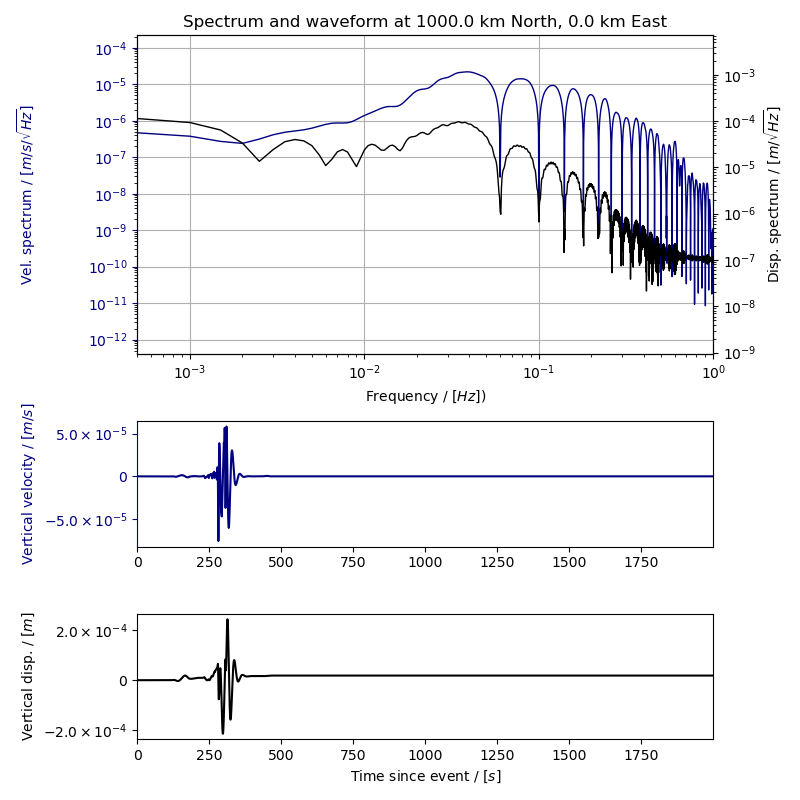

In [25]:
ns, es       = 1000e3, 0e3
### Plot one of the waveforms for check
fig = SEISMO.plot_traces(ns, es, do_interpolate=True)

### Arrange the synthetics
Sort QSSP synthetics by their location in the appropriate grid. Interpolate in time from $t=0$ to $t=tmax$.

In [26]:
reload(ar)
fig = SEISMO.arrange_interpolate_synthetics(tmax=3000, dt=8)

100%|████████████████████████████████████████| 159/159 [00:00<00:00, 6256.40it/s]                                             

Size of VEL, DIS (bytes):  477000


### Initialize the AIRGLOW class
We load atmospheric parameters, background emission, etc. 

In [53]:
### Load airglow class 
reload(ar)
AIRGLOW = ar.AirglowSignal(SEISMO)

Using Balthasar Kenda's attenuation data


### Calculate the Airglow waveforms
Can be done in parallel or in serial. It is important to check what kind of information we want to save here, as full grids can be heavy. Here, we only have few locations, so we will calculate airglow for all of them. 

In [54]:
reload(ar)

dir_save="./results_detectability/"
if not os.path.exists(dir_save):
    os.makedirs(dir_save)
dir_save += "singletrace_"
list_inorth, list_ieast = AIRGLOW.iNN, [0 for i in range(AIRGLOW.Nn)]
# print(list_inorth, list_ieast)

### Calculation of the Nightglow 
AIRGLOW.calculate_1_27_airglow(list_ieast, list_inorth, loc_save_idx=[],
                                do_parallel=True, 
                                fourier_filtering=False,   ### Use time filtering 
                                dir_save = dir_save,
                                time_save = AIRGLOW.t_new) ### Save all timesteps 

### Calculation of the Dayglow
AIRGLOW.calculate_4_28_airglow(list_ieast, list_inorth, loc_save_idx=[],
                        do_parallel=True, 
                        dir_save=dir_save, 
                        time_save = AIRGLOW.t_new) ### Save all timesteps 

(East, North) location indices that will be saved:  []


100%|████████████████████████████████████████| 159/159 [00:00<00:00, 2562.14it/s]                                             


Time for airglow calculation: 0.2 s
Re-aranging gridded wavefield...


100%|████████████████████████████████████████| 159/159 [00:00<00:00, 11708.53it/s]                                            


Saving gridded wavefield...
Grid save completed.
(East, North) location indices that will be saved:  []


100%|████████████████████████████████████████| 159/159 [00:00<00:00, 2644.17it/s]                                             


Time for dayglow calculation: 0.2 s
Re-aranging gridded dayglow wavefield...


100%|████████████████████████████████████████| 159/159 [00:00<00:00, 11626.27it/s]                                            


Saving gridded dayglow wavefield...
Grid save completed.


### Plot the traces
For the moment, we only have nightglow

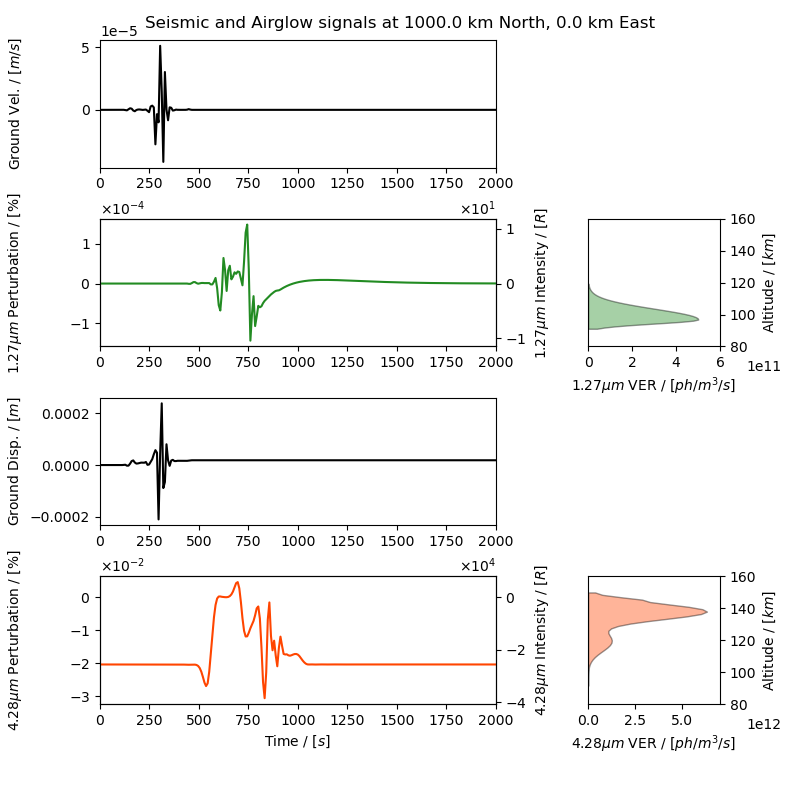

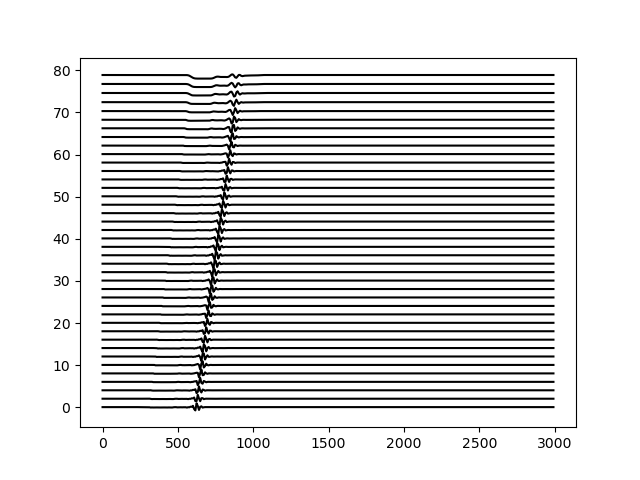

In [55]:
from matplotlib.gridspec import GridSpec
plt.close("all")
c_dayglow = "orangered"
c_nightglow = "forestgreen"
### Load VER grids:
I_nightglow = np.load(dir_save + "nightglow_I_t.npy")
VER_Vz_nightglow = np.load(dir_save + "nightglow_dver_t.npy")
I_dayglow = np.load(dir_save + "dayglow_I_t.npy")
VER_Uz_dayglow = np.load(dir_save + "dayglow_dver_t.npy")

time = AIRGLOW.t_new
###
z_ver_127 = AIRGLOW.z_1_27_calc_m  ### Always in meter
z_ver_428 = AIRGLOW.z_4_28_calc_m  ### Always in meter
### Background VER 
VER_127 = AIRGLOW.f_VER_1_27(z_ver_127) 
VER_428 = AIRGLOW.f_VER_4_28(z_ver_428)
### Background Intensity 
I_background_nightglow = AIRGLOW.I_background_nightglow
I_background_dayglow   = AIRGLOW.I_background_dayglow


### Select a location: 
ns, es       = 1000e3, 0e3
idx = np.argmin(np.sqrt((AIRGLOW.NN-ns)**2+(AIRGLOW.EE-es)**2)) 
i_east, i_north = 0, idx

### Create figure
fig = plt.figure(figsize=(8, 8))
fig.suptitle("Seismic and Airglow signals at {:.1f} km North, {:.1f} km East".format(AIRGLOW.NN[i_north]/1e3,
                                                                                    AIRGLOW.EE[i_east]/1e3))
gs = GridSpec(4, 2, figure=fig, width_ratios=[3, 1])

axes = [fig.add_subplot(gs[i, 0]) for i in range(4)] 
axv1 = fig.add_subplot(gs[1, 1])
axv2 = fig.add_subplot(gs[3, 1])

axes[0].plot(time, AIRGLOW.VEL[i_east, i_north,:], c="k")
axes[0].set_ylabel(r"Ground Vel. / [$m/s$]")
###
axes[1].plot(time, I_nightglow[i_east, i_north, :]/I_background_nightglow*100, ls=" ")#ls="-", c="b")
axes[1].set_ylabel(r"1.27$\mu m$ Perturbation / [%]")
axes[1].ticklabel_format(axis='y', style='sci', scilimits=(0,0), useMathText=True)
ax1b = axes[1].twinx()   ### Plot as purcentage of background intensity 
ax1b.plot(time, I_nightglow[i_east, i_north, :], c=c_nightglow)
ax1b.set_ylabel(r"1.27$\mu m$ Intensity / [$R$]")
ax1b.ticklabel_format(style='sci', axis='y', scilimits=(0,0), useMathText=True)

###
axes[2].plot(time, AIRGLOW.DIS[i_east, i_north,:], c="k")
axes[2].set_ylabel(r"Ground Disp. / [$m$]")
###
axes[3].plot(time, I_dayglow[i_east, i_north, :]/I_background_dayglow*100, ls=" ")#ls="-", c="b")
axes[3].set_ylabel(r"4.28$\mu m$ Perturbation / [%]")
axes[3].ticklabel_format(axis='y', style='sci', scilimits=(0,0), useMathText=True)
ax3b = axes[3].twinx()   ### Plot as purcentage of background intensity 
ax3b.plot(time, I_dayglow[i_east, i_north, :], c=c_dayglow)
ax3b.set_ylabel(r"4.28$\mu m$ Intensity / [$R$]")
ax3b.ticklabel_format(style='sci', axis='y', scilimits=(0,0), useMathText=True)
        

### Plot VER profiles 
axv1.fill_betweenx(z_ver_127/1e3, 0, VER_127, edgecolor="k", facecolor=c_nightglow, alpha=0.4)
axv1.set_ylabel(r"Altitude / [$km$]")
axv1.set_xlabel(r"1.27$\mu m$ VER / [$ph/m^3/s$]")
###
axv2.fill_betweenx(z_ver_428/1e3, 0, VER_428, edgecolor="k", facecolor=c_dayglow, alpha=0.4)
axv2.set_ylabel(r"Altitude / [$km$]")
axv2.set_xlabel(r"4.28$\mu m$ VER / [$ph/m^3/s$]")


###
axes[-1].set_xlabel("Time / [$s$]")
for ax in axes:
    ax.set_xlim(0,2000)
axv1.set_xlim(0, 6e11)
axv2.set_xlim(0, 7e12)
for ax in [axv1, axv2]:
    ax.set_ylim(80,160)
    ax.yaxis.set_label_position("right")
    ax.yaxis.tick_right()
    ax.xaxis.get_offset_text().set_position((1.2, 1.0))  # (x, y) in axis coordinates
    ax.xaxis.get_offset_text().set_horizontalalignment('left')
    ax.xaxis.get_offset_text().set_verticalalignment('bottom')

fig.subplots_adjust(hspace=0.4, wspace=0.35, bottom=0.12, top=0.95)
fig.align_labels()
fig.savefig(dir_save + "Nightglow_Dayglow_traces.png", dpi=300)

fix, ax = plt.subplots()
for i in range(VER_Uz_dayglow.shape[2]):
    wv =  VER_Uz_dayglow[i_east, i_north,i,:,0]
    ax.plot(time, wv/np.max(np.abs(wv)) + i*2, c="k")